In [1]:
import sys
sys.path.append(r"C:\\Users\\Lenovo\\Desktop")

In [2]:
from torch.utils.data import Dataset
from PIL import Image
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

In [3]:
# traindir = '././data_of_train1/train'

valdir = '././data_of_valid2/test-copy'
traindir = '././data_of_train1/train'
# traindir = '././data_of_train1/train-copy'

# valdir = '././waste/combined_data_mini/val'
# traindir = '././waste/combined_data/train'

train_transforms  = transforms.Compose([
        transforms.Resize(224),
        # transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomPerspective(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
test_transforms = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

train_datasets = datasets.ImageFolder(traindir, train_transforms)
dataset_test = datasets.ImageFolder(valdir, test_transforms)

data_loader = torch.utils.data.DataLoader(
    train_datasets, batch_size=32, shuffle=True, num_workers=3, pin_memory=True)
val_dataloader = torch.utils.data.DataLoader(
    dataset_test, batch_size=32, shuffle=False, num_workers=3, pin_memory=True)

classes = data_loader.dataset.classes
print(classes)

['0', '1', '2', '3', '4', '5', '6']


In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = torch.device('cpu')
print(device)

cuda


In [5]:
def he_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [6]:
import torchvision.models as models
model = models.densenet121(pretrained=True)
print(model)
model.train()
import torch.nn as nn
model.classifier = nn.Linear(model.classifier.in_features, 7)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\anaconda\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [8]:

num_epochs = 20
lr = 1e-3
weight_decay = 5e-4

loss = nn.CrossEntropyLoss()

optimizer = torch.optim.Adamax(model.parameters(), lr=lr, weight_decay=weight_decay)
# optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, alpha=0.99, eps=1e-08, weight_decay=weight_decay, momentum=momentum)
# scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(data_loader), epochs=num_epochs)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [9]:
model = model.to(device)
print(next(model.parameters()).device)
print(torch.cuda.is_available())  # Should return True if CUDA is available
print(torch.cuda.current_device())  # Returns the index of the current device
print(torch.cuda.get_device_name(torch.cuda.current_device()))  # Returns the name of the current device



cuda:0
True
0
NVIDIA GeForce RTX 3060 Laptop GPU


Epoch 1: Train Loss = 1.5534, Train F1 = 0.3920, Val Loss = 1.7192, Val F1 = 0.3133
Epoch 2: Train Loss = 1.4223, Train F1 = 0.4547, Val Loss = 1.7400, Val F1 = 0.3309
Epoch 3: Train Loss = 1.3643, Train F1 = 0.4805, Val Loss = 1.8183, Val F1 = 0.3115
Epoch 4: Train Loss = 1.3258, Train F1 = 0.4984, Val Loss = 1.7801, Val F1 = 0.3407
Epoch 5: Train Loss = 1.2973, Train F1 = 0.5103, Val Loss = 1.9717, Val F1 = 0.2912
Epoch 6: Train Loss = 1.2707, Train F1 = 0.5207, Val Loss = 2.1188, Val F1 = 0.2595
Epoch 7: Train Loss = 1.2522, Train F1 = 0.5283, Val Loss = 1.8168, Val F1 = 0.3314
Epoch 8: Train Loss = 1.2353, Train F1 = 0.5360, Val Loss = 1.8798, Val F1 = 0.3291
Epoch 9: Train Loss = 1.2202, Train F1 = 0.5412, Val Loss = 1.7971, Val F1 = 0.3465
Epoch 10: Train Loss = 1.2056, Train F1 = 0.5483, Val Loss = 2.0474, Val F1 = 0.2733


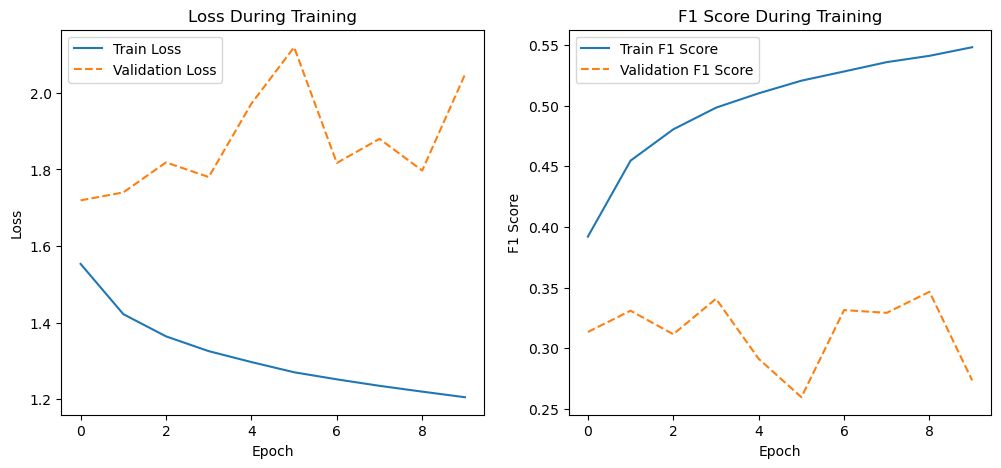

In [12]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import numpy as np

def evaluate_model(model, data_loader):
    model.eval()
    all_labels = []
    all_predictions = []
    total_loss = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            l = loss(outputs, labels)
            total_loss += l.item()
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    return avg_loss, f1

def train_model(model, train_loader, val_loader, loss, optimizer, epochs=10, lr=0.01):
    train_losses = []
    val_losses = []
    train_f1_scores = []
    val_f1_scores = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        all_labels = []
        all_predictions = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            l = loss(outputs, labels)
            l.backward()
            optimizer.step()

            total_loss += l.item()
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

        train_loss = total_loss / len(train_loader)
        train_f1 = f1_score(all_labels, all_predictions, average='weighted')

        val_loss, val_f1 = evaluate_model(model, val_loader)

        train_losses.append(train_loss)
        train_f1_scores.append(train_f1)
        val_losses.append(val_loss)
        val_f1_scores.append(val_f1)

        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Train F1 = {train_f1:.4f}, Val Loss = {val_loss:.4f}, Val F1 = {val_f1:.4f}")

    return train_losses, train_f1_scores, val_losses, val_f1_scores

def plot_metrics(train_losses, train_f1_scores, val_losses, val_f1_scores):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss', linestyle='--')
    plt.title('Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_f1_scores, label='Train F1 Score')
    plt.plot(val_f1_scores, label='Validation F1 Score', linestyle='--')
    plt.title('F1 Score During Training')
    plt.xlabel('Epoch')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.show()

train_losses, train_f1_scores, val_losses, val_f1_scores = train_model(model, data_loader, val_dataloader, loss, optimizer, epochs=10, lr=0.01)
plot_metrics(train_losses, train_f1_scores, val_losses, val_f1_scores)
